<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/2026.05/Lab4_PE_keithley_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

v0.2.1 Automated measurements. Diodes

v0.2.2 Lamp + Filters

v0.3.0 Du Bridges method extracting V0

v0.3.1 Resume added


# Resume

## Method

Classical scheme of voltage measurements on photocell with voltmeter connected in parallele was neglected since it   distorts small current measurements. We connected to the photocell [RCA 929](https://frank.pocnet.net/sheets/049/9/929.pdf) with picoammter Keithley 2400  to  measure current, set and measures voltage using minimum wires. We automated Volt-Ampere curve scann using [python app](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/photoelectric_v2.py).

We took blue, red, green and yellow diodes and measured their scpectrum with spectrometer Avantes. We measured set of optical filters and spectrum of white lamps without filters.  See  [results](https://github.com/tphlabs/data/tree/main/Lab4_SP/2026.04) on github.

Then we measured volt-ampere curves and linearized them using [Du Bridges](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/jpsj.8.723.pdf) method to find stopping voltage $V_0$ for various light wavlengths and intensities.

## Results

Qualitatevly the results looks  reasonable: the stopping voltage increases with increasing light frequency as expected. Quantitatevly, the $V_0(\nu)$ linear regression has slope reasonably close to expected $h/e$ value, though the data points are not lying on a straight line with expected uncertainty.


In [ ]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c

In [ ]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

#Volt-ampere curve


# Dark current

In [ ]:
# Calculated from ambient light data
dark_min = -158e-12 #A
dark_max = -204e-12
dark = (dark_min + dark_max) / 2


Text(0, 0.5, 'Current, A')

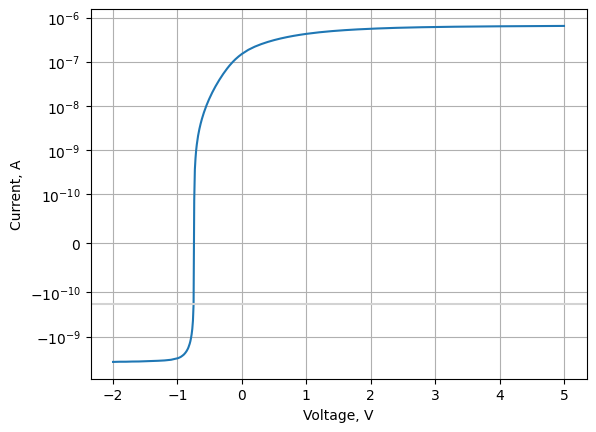

In [ ]:
url = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.05/blue.csv'
txt = requests.get(url).text
LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(txt.splitlines(), \
                                                  delimiter=',', skip_header=1, unpack=True)
mask = LED_V == 12

V = V_set[mask]
I = I_avg_A[mask]
plt.plot(V, I)
plt.yscale('symlog', linthresh=1e-10)
plt.axhline(dark, color='lightgray')
plt.grid()
plt.xlabel('Voltage, V')
plt.ylabel('Current, A')

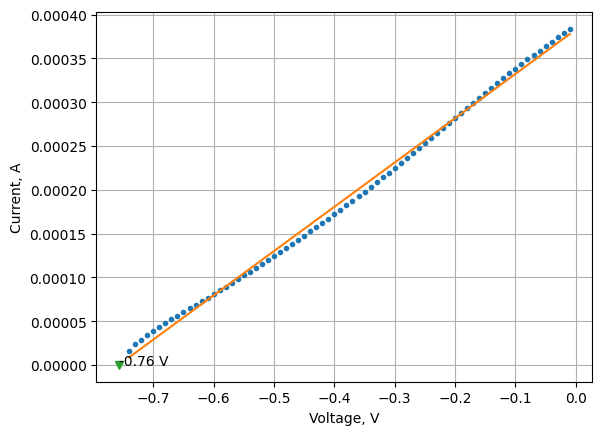

In [ ]:

def find_root(V, I):
  mask = (I > dark) & ( V < 0 )
  x = V[mask]
  y = np.sqrt(I[mask]-dark)
  fit = linregress(x, y)
  V0 = - fit.intercept / fit.slope
  return V0

normalization_parameter = I[V==1]
Inorm = (I - dark) / normalization_parameter

mask = (I > dark) & ( V < 0 )
x = V[mask]
y = np.sqrt(I[mask]-dark)
plt.plot(x, y, '.')
fit = linregress(x, y)
plt.plot(x, fit.slope * x + fit.intercept)
plt.grid()
plt.xlabel('Voltage, V')
plt.ylabel('Current, A')
V0 = find_root(V, I)
plt.plot(V0, 0, 'v')
plt.annotate(f'{V0:.2f} V', (V0, 0))
plt.show()


/tmp/ipykernel_35051/466641072.py:52: RuntimeWarning: invalid value encountered in sqrt
  DuBridge =   np.sqrt(Inorm[condition])


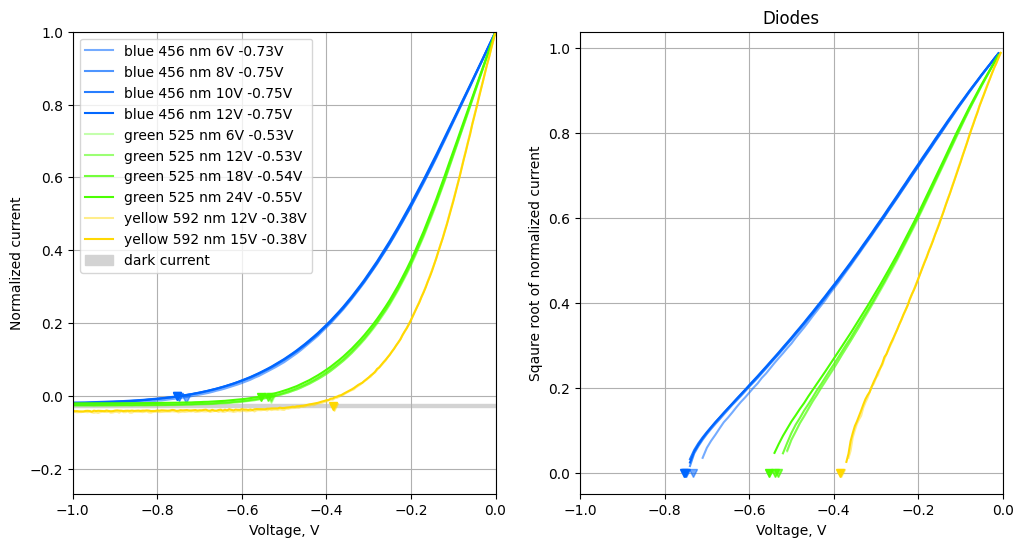

In [ ]:
NORMPOINT = 0 #V
names = ['blue', 'green', 'yellow']
waves = [456, 525, 592]
n = len(names)


fig, ax = plt.subplots(1, 2, figsize=(12,6))
plt.grid()

data = '# color wavelength power V0\n'


for i, name in enumerate(names):
  color= wavelength_to_color(waves[i])
  url = f'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.05/{name}.csv'
  txt = requests.get(url).text
  LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(txt.splitlines(), \
                                                    delimiter=',', skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power in powers:
    if power == np.min(powers):
      continue
    if power == 1:
      continue
    mask = (LED_V == power)
    V = V_set[mask]
    I = I_avg_A[mask]
    normalization_parameter = I[V==NORMPOINT]
    Inorm = I / normalization_parameter
    opacity = 0.1 + 0.89 * (power - np.min(powers)) / (np.max(powers) - np.min(powers))

    # Find points where current I crosses zero current line
    V0 = find_root(V, Inorm)
    ax[0].plot(V0, dark / normalization_parameter, color=color, alpha = opacity, marker='v')
    ax[1].plot(V0, 0, color=color, alpha = opacity, marker='v')
    data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # zero\n'

    # Find points where current I crosses dark current band
    #V0 = find_roots(V, I - dark_min)
    #plt.plot(V0, dark_min, color=color, alpha = opacity, marker='v')
    #ata += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # left\n'

    #V0 = find_roots(V, I - dark_max)
    #plt.plot(V0, dark_max, color=color, alpha = opacity, marker='^')
    #data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # right\n'


    ax[0].plot(V, Inorm, color=color, alpha=opacity, label=f'{name} {waves[i]:.0f} nm {power:.0f}V {V0:.2f}V')
    condition = Inorm < 1
    DuBridge =   np.sqrt(Inorm[condition])
    ax[1].plot(V[condition], DuBridge, color=color, alpha=opacity, label=f'{name} {power:.0f}V {V0:.2f}V')


ax[0].fill_between(V, dark_min / normalization_parameter, \
                 dark_max / normalization_parameter, \
                 color='lightgray', label='dark current')
ax[0].legend()
ax[0].set_xlim(-1, 0)
ax[0].set_ylim(top=1)
ax[0].grid()
ax[1].set_xlim(-1, 0)

ax[0].set_xlabel('Voltage, V')
ax[0].set_ylabel('Normalized current')
ax[1].set_xlabel('Voltage, V')
ax[1].set_ylabel(r'Sqaure root of normalized current')
plt.title('Diodes')
plt.show()


/tmp/ipykernel_35051/3848719566.py:56: RuntimeWarning: invalid value encountered in sqrt
  DuBridge =   np.sqrt(Inorm[condition])


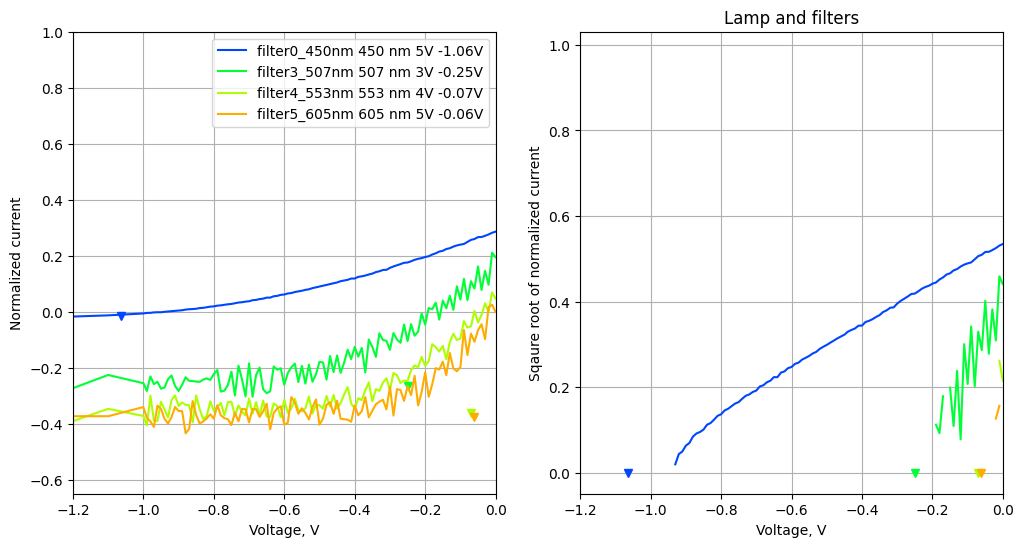

In [ ]:
names = ['blue', 'green', 'yellow']
waves = [456, 525, 592]
n = len(names)


NORMPOINT = 1 #V

names += ['filter0_450nm', 'filter3_507nm', 'filter4_553nm', 'filter5_605nm']
waves += [450, 507, 553, 605]




fig, ax = plt.subplots(1, 2, figsize=(12,6))
plt.grid()



for i, name in enumerate(names):
  if i < n:
    continue
  color= wavelength_to_color(waves[i])
  url = f'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/2026.05/{name}.csv'
  txt = requests.get(url).text
  LED_V,V_set,V_actual,I_avg_A, I_std_A, _, _ = np.genfromtxt(txt.splitlines(), \
                                                    delimiter=',', skip_header=1, unpack=True)

  powers = np.unique(LED_V)

  for power in powers:
    mask = (LED_V == power)
    V = V_set[mask]
    I = I_avg_A[mask]
    normalization_parameter = I[V==NORMPOINT]
    Inorm = I  / normalization_parameter  # no dark!!
    opacity = 1

    # Find points where current I crosses zero current line
    V0 = find_root(V, Inorm)
    ax[0].plot(V0, dark / normalization_parameter, color=color, alpha = opacity, marker='v')
    ax[1].plot(V0, 0, color=color, alpha = opacity, marker='v')
    data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # zero\n'

    # Find points where current I crosses dark current band
    #V0 = find_roots(V, I - dark_min)
    #plt.plot(V0, dark_min, color=color, alpha = opacity, marker='v')
    #ata += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # left\n'

    #V0 = find_roots(V, I - dark_max)
    #plt.plot(V0, dark_max, color=color, alpha = opacity, marker='^')
    #data += f'{i} {waves[i]} {power:.0f} {-V0:.3f} # right\n'


    ax[0].plot(V, Inorm, color=color, alpha=opacity, label=f'{name} {waves[i]:.0f} nm {power:.0f}V {V0:.2f}V')
    condition = Inorm < 1
    DuBridge =   np.sqrt(Inorm[condition])
    ax[1].plot(V[condition], DuBridge, color=color, alpha=opacity, label=f'{name} {power:.0f}V {V0:.2f}V')


ax[0].legend()
ax[0].set_xlim(-1.2, 0)
ax[0].set_ylim(top=1)
ax[0].grid()
ax[1].set_xlim(-1.2, 0)

ax[0].set_xlabel('Voltage, V')
ax[0].set_ylabel('Normalized current')
ax[1].set_xlabel('Voltage, V')
ax[1].set_ylabel(r'Sqaure root of normalized current')
plt.title('Lamp and filters')
plt.show()


In [ ]:
print(data)

# color wavelength power V0
0 456 6 0.732 # zero
0 456 8 0.749 # zero
0 456 10 0.753 # zero
0 456 12 0.753 # zero
1 525 6 0.532 # zero
1 525 12 0.531 # zero
1 525 18 0.539 # zero
1 525 24 0.554 # zero
2 592 12 0.382 # zero
2 592 15 0.384 # zero
3 450 5 1.063 # zero
4 507 3 0.249 # zero
5 553 4 0.071 # zero
6 605 5 0.062 # zero



# Plank's constant and Work potential determination

$$
 e V_0(\nu) = h \nu -  e W
$$

/tmp/ipykernel_35051/9855336.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / wl


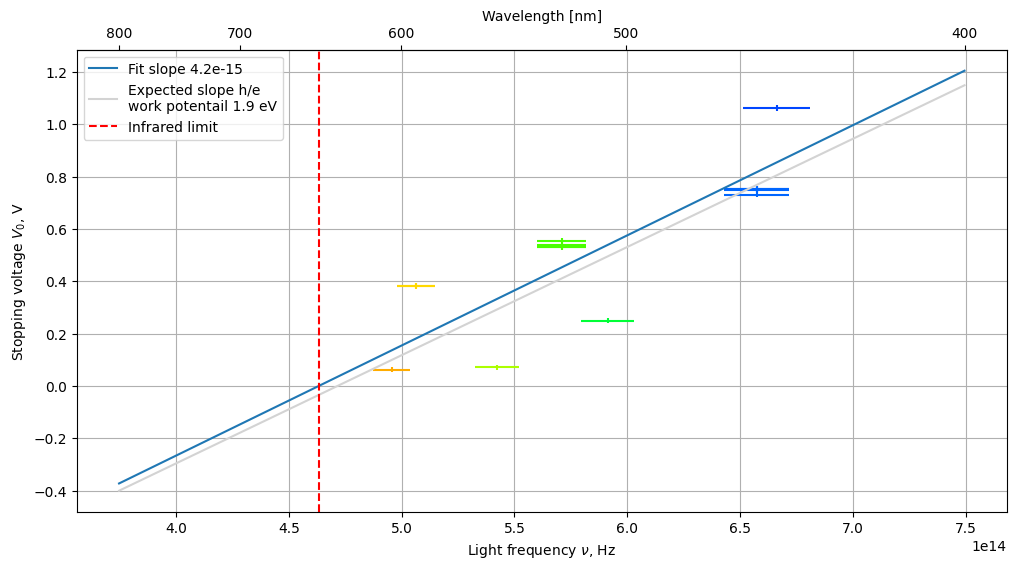

In [ ]:
offset_expected = 1.95 # V, for Cs-Sb Photocathode

def linear(nu, slope):
    return slope * nu - offset_expected

def wl2freq(wl):
    return c / wl


def freq2wl(nu):
    return c / nu * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(freq2wl, wl2freq))
secax.set_xlabel('Wavelength [nm]')


ix, wl, power, V0 = np.genfromtxt(data.splitlines()).T


relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
nu_err = nu * relative_error
energy_err = energy * relative_error
V_err = 0.01 # V
# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset
popt, pcov = curve_fit(linear, nu , V0)
slope = popt[0]
#offset = popt[1]
err = np.sqrt(np.diag(pcov))
slope_err = err[0]
#offset_err = err[1]

# errors in coeffs of linear regression, as in Taylor Ch8.
#y = V0
#x = nu
#N = len(y)
#sigma2_y = np.sum( (y - offset_expected - slope * x)**2) / (N - 2)
#Delta = N * np.sum(x**2) - np.sum(x)**2
#offset_err = np.sqrt(sigma2_y * np.sum(x**2) / Delta)
#slope_err = np.sqrt(N * sigma2_y / Delta)

for i in range(len(V0)):
  ind = int(ix[i])
  plt.errorbar(nu[i], V0[i], yerr=V_err, xerr=nu_err[i], ls='', color=wavelength_to_color(wl[i]*1e9))

wl_dense = np.linspace(400, 800)  * 1e-9
nu_dense = c / wl_dense

plt.plot(nu_dense, linear(nu_dense, slope), label=f'Fit slope {slope:.1e}')
plt.plot(nu_dense, linear(nu_dense, h/e) , color='lightgray', label=f'Expected slope h/e\nwork potentail {offset_expected:.1f} eV')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light frequency $\nu$, Hz')
plt.ylabel(r'Stopping voltage $V_0$, V')
Infrared_PhotoEmission_limit = offset_expected / slope
plt.axvline(Infrared_PhotoEmission_limit, color='red', ls='--', label='Infrared limit')
plt.legend()
plt.show()
#plt.xlim(0.2, 1)
plt.show()



In [ ]:
h/e, slope, h / e / slope

(4.135667696923859e-15,
 np.float64(4.209869684584729e-15),
 np.float64(0.9823742792009511))